# A Systematic Study of Linguistic Robustness in Small LLMs

## Research Question

This project investigates:
1. Do different paraphrase types produce systematically different levels of output inconsistency?
2. Does input formality independently influence model output consistency?
3. Is output inconsistency model-dependent or task-dependent?

---

## Environment Setup and Google Drive Mount

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# Set project root in Google Drive
PROJECT_ROOT = '/content/drive/MyDrive/nlp_project_2'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current directory: {os.getcwd()}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/nlp_project_2
Current directory: /content/drive/MyDrive/nlp_project_2


## Directory Structure Creation

In [ ]:
# Create project directory structure
directories = [
    'data/raw',
    'data/processed',
    'paraphrases',
    'models',
    'evaluation',
    'results/figures',
    'results/tables',
    'code',
    'cache'
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

print("Directory structure created:")
for directory in directories:
    print(f" successfully created: {directory}")

Directory structure created:
 successfully created: data/raw
 successfully created: data/processed
 successfully created: paraphrases
 successfully created: models
 successfully created: evaluation
 successfully created: results/figures
 successfully created: results/tables
 successfully created: code
 successfully created: cache


## Install Dependencies

In [ ]:
!pip install -q transformers datasets torch nltk bert-score rouge-score scikit-learn pandas numpy matplotlib seaborn tqdm spacy
!python -m spacy download en_core_web_lg

print("All dependencies installed successfully.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed successfully.


## Import Libraries

In [ ]:
import json
import pickle
import hashlib
from pathlib import Path
from typing import Dict, List, Any, Optional
from dataclasses import dataclass, asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForSequenceClassification
from datasets import load_dataset

import nltk
from nltk.corpus import wordnet
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import spacy
import logging
logging.getLogger("bert_score").setLevel(logging.ERROR)

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Pre-load bertscore model once and reuse
from bert_score import BERTScorer
_bert_scorer = BERTScorer(lang='en', model_type='roberta-large', rescale_with_baseline=False)

# Download NLTK data
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt', quiet=True)

# Load spacy model
nlp = spacy.load('en_core_web_lg')

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu


## Configuration Class

In [ ]:
@dataclass
class Config:
    """Central configuration for the project"""

    # Models
    models: List[str] = None

    # Tasks
    tasks: List[str] = None

    # Paraphrase types
    paraphrase_types: List[str] = None

    # Data
    num_samples_per_task: int = 300

    # Generation parameters
    max_length: int = 128
    temperature: float = 0.7
    top_p: float = 0.9

    # Paths
    project_root: str = PROJECT_ROOT

    def __post_init__(self):
        if self.models is None:
            self.models = ['google/flan-t5-small', 'google/mt5-small']
        if self.tasks is None:
            self.tasks = ['sentiment', 'qa', 'generation']
        if self.paraphrase_types is None:
            self.paraphrase_types = ['lexical', 'syntactic', 'formality', 'negation']

config = Config()
print("Configuration:")
print(f"  Models: {config.models}")
print(f"  Tasks: {config.tasks}")
print(f"  Paraphrase types: {config.paraphrase_types}")
print(f"  Samples per task: {config.num_samples_per_task}")

Configuration:
  Models: ['google/flan-t5-small', 'google/mt5-small']
  Tasks: ['sentiment', 'qa', 'generation']
  Paraphrase types: ['lexical', 'syntactic', 'formality', 'negation']
  Samples per task: 300


## Utility Functions

In [ ]:
def save_results(data: Any, filename: str, subdir: str = 'results'):
    """Save results to JSON file"""
    filepath = os.path.join(config.project_root, subdir, filename)
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

    with open(filepath, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"Saved: {filepath}")


def load_results(filename: str, subdir: str = 'results') -> Any:
    """Load results from JSON file"""
    filepath = os.path.join(config.project_root, subdir, filename)
    with open(filepath, 'r') as f:
        return json.load(f)


def save_code(code: str, filename: str):
    """Save code block to file"""
    filepath = os.path.join(config.project_root, 'code', filename)
    with open(filepath, 'w') as f:
        f.write(code)
    print(f"Code saved: {filepath}")


def read_code(filename: str) -> str:
    """Read code from file"""
    filepath = os.path.join(config.project_root, 'code', filename)
    with open(filepath, 'r') as f:
        return f.read()


def get_cache_path(key: str) -> str:
    """Generate cache file path from key"""
    hash_key = hashlib.md5(key.encode()).hexdigest()
    return os.path.join(config.project_root, 'cache', f'{hash_key}.pkl')


def load_from_cache(key: str) -> Optional[Any]:
    """Load data from cache if exists"""
    cache_path = get_cache_path(key)
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            print(f"Loading from cache: {key}")
            return pickle.load(f)
    return None


def save_to_cache(key: str, data: Any):
    """Save data to cache"""
    cache_path = get_cache_path(key)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved to cache: {key}")


print("Utility functions defined.")

Utility functions defined.


## Data Loading Functions

In [ ]:
def load_sentiment_data(num_samples: int = 100) -> List[Dict]:
    """Load sentiment classification data from SST-2"""
    cache_key = f'sentiment_data_{num_samples}'
    cached = load_from_cache(cache_key)
    if cached is not None:
        return cached

    dataset = load_dataset('glue', 'sst2', split='validation')
    samples = []

    for i, item in enumerate(dataset):
        if i >= num_samples:
            break
        samples.append({
            'task': 'sentiment',
            'input': item['sentence'],
            'label': 'positive' if item['label'] == 1 else 'negative',
            'prompt': f"Classify the sentiment of this sentence as positive or negative: {item['sentence']}"
        })

    save_to_cache(cache_key, samples)
    return samples


def load_qa_data(num_samples: int = 100) -> List[Dict]:
    """Load question answering data from SQuAD"""
    cache_key = f'qa_data_{num_samples}'
    cached = load_from_cache(cache_key)
    if cached is not None:
        return cached

    dataset = load_dataset('squad', split='validation')
    samples = []

    for i, item in enumerate(dataset):
        if i >= num_samples:
            break
        samples.append({
            'task': 'qa',
            'input': item['question'],
            'context': item['context'],
            'answer': item['answers']['text'][0],
            'prompt': f"Context: {item['context'][:300]}... Question: {item['question']}"
        })

    save_to_cache(cache_key, samples)
    return samples


def load_generation_data(num_samples: int = 100) -> List[Dict]:
    """Load open-ended generation prompts"""
    cache_key = f'generation_data_{num_samples}'
    cached = load_from_cache(cache_key)
    if cached is not None:
        return cached

    # Curated prompts for open-ended generation
    base_prompts = [
        "Explain the importance of recycling.",
        "Describe a typical day in the life of a teacher.",
        "What are the benefits of reading books?",
        "How does exercise improve mental health?",
        "Why is teamwork important in the workplace?",
        "What makes a good leader?",
        "Describe the process of photosynthesis.",
        "What are the effects of climate change?",
        "How can technology improve education?",
        "Why is learning a second language beneficial?"
    ]

    samples = []
    for i in range(num_samples):
        prompt = base_prompts[i % len(base_prompts)]
        samples.append({
            'task': 'generation',
            'input': prompt,
            'prompt': prompt
        })

    save_to_cache(cache_key, samples)
    return samples


def load_all_data(config: Config) -> Dict[str, List[Dict]]:
    """Load all datasets"""
    data = {}

    if 'sentiment' in config.tasks:
        print("Loading sentiment data...")
        data['sentiment'] = load_sentiment_data(config.num_samples_per_task)

    if 'qa' in config.tasks:
        print("Loading QA data...")
        data['qa'] = load_qa_data(config.num_samples_per_task)

    if 'generation' in config.tasks:
        print("Loading generation data...")
        data['generation'] = load_generation_data(config.num_samples_per_task)

    # Save to disk
    save_results(data, 'raw_data.json', 'data/raw')

    print(f"\nLoaded data summary:")
    for task, samples in data.items():
        print(f"  {task}: {len(samples)} samples")

    return data


print("Data loading functions defined.")

Data loading functions defined.


## Paraphrase Generation Functions

In [ ]:
class ParaphraseGenerator:
    """Generate paraphrases across four linguistic categories"""

    def __init__(self):
        self.nlp = nlp

    def lexical_substitution(self, text: str) -> str:
        """Replace content words with synonyms"""
        doc = self.nlp(text)
        tokens = []

        for token in doc:
            # Only substitute nouns, verbs, adjectives, adverbs
            if token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']:
                synonyms = self._get_synonyms(token.text, token.pos_)
                if synonyms:
                    tokens.append(synonyms[0])
                else:
                    tokens.append(token.text)
            else:
                tokens.append(token.text)

        # Reconstruct with proper spacing
        result = ""
        for i, token in enumerate(doc):
            result += tokens[i]
            if i < len(doc) - 1 and not doc[i+1].is_punct:
                result += " "

        return result

    def syntactic_restructuring(self, text: str) -> str:
        """Restructure sentence syntax (placeholder - rule-based transformations)"""
        doc = self.nlp(text)

        # Simple transformations: passive voice conversion, clause reordering
        # This is a simplified version - full implementation would use dependency parsing

        # Example: "The cat ate the fish" -> "The fish was eaten by the cat"
        # For now, we'll use simple pattern-based transformations

        result = text

        # Add question tag if statement
        if text.endswith('.'):
            result = text[:-1] + ", right?"

        return result

    def formality_shift(self, text: str, to_formal: bool = True) -> str:
        """Shift register between formal and informal"""
        if to_formal:
            # Informal -> Formal
            replacements = {
                "don't": "do not",
                "can't": "cannot",
                "won't": "will not",
                "it's": "it is",
                "what's": "what is",
                "gonna": "going to",
                "wanna": "want to",
                "gotta": "have to",
                "kinda": "kind of",
                "sorta": "sort of",
                "yeah": "yes",
                "nope": "no"
            }
        else:
            # Formal -> Informal
            replacements = {
                "do not": "don't",
                "cannot": "can't",
                "will not": "won't",
                "it is": "it's",
                "what is": "what's",
                "going to": "gonna",
                "want to": "wanna",
                "have to": "gotta",
                "kind of": "kinda",
                "sort of": "sorta",
                "yes": "yeah",
                "no": "nope"
            }

        result = text
        for old, new in replacements.items():
            result = result.replace(old, new)
            result = result.replace(old.capitalize(), new.capitalize())

        return result

    def negation_based(self, text: str) -> str:
        """Introduce negation while preserving polarity"""
        # Simple negation patterns
        # "This is good" -> "This is not bad"

        antonym_pairs = {
            'good': 'bad',
            'great': 'terrible',
            'positive': 'negative',
            'happy': 'sad',
            'love': 'hate',
            'like': 'dislike',
            'excellent': 'poor',
            'wonderful': 'awful'
        }

        result = text
        for word, antonym in antonym_pairs.items():
            if word in text.lower():
                result = result.replace(word, f"not {antonym}")
                result = result.replace(word.capitalize(), f"Not {antonym}")
                break

        return result

    def _get_synonyms(self, word: str, pos: str) -> List[str]:
        """Get synonyms from WordNet"""
        pos_map = {
            'NOUN': wordnet.NOUN,
            'VERB': wordnet.VERB,
            'ADJ': wordnet.ADJ,
            'ADV': wordnet.ADV
        }

        wn_pos = pos_map.get(pos)
        if not wn_pos:
            return []

        synsets = wordnet.synsets(word, pos=wn_pos) or []
        synonyms = set()

        for synset in synsets[:2]:  # Only first 2 synsets
            for lemma in synset.lemmas():
                if lemma.name().lower() != word.lower():
                    synonyms.add(lemma.name().replace('_', ' '))

        return list(synonyms)[:3]  # Return top 3

    def generate_paraphrases(self, text: str, types: List[str]) -> Dict[str, str]:
        """Generate all paraphrase types for input text"""
        paraphrases = {'original': text}

        if 'lexical' in types:
            paraphrases['lexical'] = self.lexical_substitution(text)

        if 'syntactic' in types:
            paraphrases['syntactic'] = self.syntactic_restructuring(text)

        if 'formality' in types:
            paraphrases['formality'] = self.formality_shift(text, to_formal=True)

        if 'negation' in types:
            paraphrases['negation'] = self.negation_based(text)

        return paraphrases


print("Paraphrase generation class defined.")

Paraphrase generation class defined.


## Generate Paraphrases for All Data

In [ ]:
def generate_all_paraphrases(data: Dict[str, List[Dict]], config: Config) -> Dict:
    """Generate paraphrases for all samples across all tasks"""
    cache_key = f'paraphrases_all_{config.num_samples_per_task}'
    cached = load_from_cache(cache_key)
    if cached is not None:
        return cached

    generator = ParaphraseGenerator()
    all_paraphrases = {}

    for task, samples in data.items():
        print(f"\nGenerating paraphrases for {task}...")
        task_paraphrases = []

        for sample in tqdm(samples, desc=task):
            input_text = sample['input']
            paraphrases = generator.generate_paraphrases(input_text, config.paraphrase_types)

            sample_with_paraphrases = sample.copy()
            sample_with_paraphrases['paraphrases'] = paraphrases
            task_paraphrases.append(sample_with_paraphrases)

        all_paraphrases[task] = task_paraphrases

    # Save results
    save_results(all_paraphrases, 'paraphrases_all.json', 'paraphrases')
    save_to_cache(cache_key, all_paraphrases)

    print("\nParaphrase generation complete.")
    return all_paraphrases


print("Paraphrase batch generation function defined.")

Paraphrase batch generation function defined.


## Model Loading and Inference

In [ ]:
class ModelRunner:
    """Load models and run inference"""

    def __init__(self, model_name: str, device: str = 'cuda'):
        self.model_name = model_name
        self.device = device
        self.tokenizer = None
        self.model = None
        self._load_model()

    def _load_model(self):
        """Load model and tokenizer"""
        print(f"Loading {self.model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name).to(self.device)
        self.model.eval()
        print(f"Model loaded on {self.device}")

    def generate(self, prompt: str, max_length: int = 128, temperature: float = 0.7, top_p: float = 0.9) -> str:
        """Generate text from prompt"""
        inputs = self.tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(self.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_length=max_length,
                temperature=temperature,
                top_p=top_p,
                do_sample=True,
                num_return_sequences=1
            )

        return self.tokenizer.decode(outputs[0], skip_special_tokens=True)

    def batch_generate(self, prompts: List[str], **kwargs) -> List[str]:
        """Generate for multiple prompts"""
        return [self.generate(p, **kwargs) for p in tqdm(prompts, desc="Generating")]


print("Model runner class defined.")

Model runner class defined.


## Run Inference on All Paraphrases

In [ ]:
def run_all_inference(paraphrases_data: Dict, config: Config) -> Dict:
    """Run inference for all models on all paraphrases"""
    cache_key = f'inference_results_{config.num_samples_per_task}'
    cached = load_from_cache(cache_key)
    if cached is not None:
        return cached

    results = {}

    for model_name in config.models:
        print(f"\n{'='*60}")
        print(f"Running inference with {model_name}")
        print(f"{'='*60}")

        runner = ModelRunner(model_name, device=device)
        model_results = {}

        for task, samples in paraphrases_data.items():
            print(f"\nTask: {task}")
            task_results = []

            for sample in tqdm(samples, desc=f"{task}"):
                sample_result = {
                    'input': sample['input'],
                    'task': task,
                    'outputs': {}
                }

                # Run inference on original + all paraphrases
                for para_type, para_text in sample['paraphrases'].items():
                    # Construct task-specific prompt
                    if task == 'sentiment':
                        prompt = f"Classify the sentiment as positive or negative: {para_text}"
                    elif task == 'qa':
                        prompt = f"Context: {sample['context'][:200]}... Question: {para_text}"
                    else:  # generation
                        prompt = para_text

                    output = runner.generate(
                        prompt,
                        max_length=config.max_length,
                        temperature=config.temperature,
                        top_p=config.top_p
                    )

                    sample_result['outputs'][para_type] = output

                task_results.append(sample_result)

            model_results[task] = task_results

        # Clean model name for file storage
        model_key = model_name.replace('/', '_')
        results[model_key] = model_results

        # Save intermediate results
        save_results(model_results, f'inference_{model_key}.json', 'evaluation')

    # Save all results
    save_results(results, 'inference_all.json', 'evaluation')
    save_to_cache(cache_key, results)

    print("\nInference complete for all models and tasks.")
    return results


print("Inference function defined.")

Inference function defined.


## Evaluation Metrics

In [ ]:
class ConsistencyEvaluator:
    """Compute consistency metrics between original and paraphrased outputs"""

    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    def compute_rouge(self, reference: str, hypothesis: str) -> Dict[str, float]:
        """Compute ROUGE scores"""
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1': scores['rouge1'].fmeasure,
            'rouge2': scores['rouge2'].fmeasure,
            'rougeL': scores['rougeL'].fmeasure
        }

    def compute_bertscore(self, references: List[str], hypotheses: List[str]) -> Dict[str, float]:
        """Compute semantic similarity using sentence embeddings (replaces BERTScore)"""
        from sklearn.metrics.pairwise import cosine_similarity
        import numpy as np

        def embed(texts):
            # Use spacy vectors (already loaded, no extra model)
            return np.array([nlp(t).vector for t in texts])

        ref_vecs = embed(references)
        hyp_vecs = embed(hypotheses)

        scores = []
        for r, h in zip(ref_vecs, hyp_vecs):
            if np.linalg.norm(r) == 0 or np.linalg.norm(h) == 0:
                scores.append(0.0)
            else:
                sim = cosine_similarity([r], [h])[0][0]
                scores.append(float(sim))

        mean_score = float(np.mean(scores))
        return {
            'bertscore_precision': mean_score,
            'bertscore_recall': mean_score,
            'bertscore_f1': mean_score
        }

    def exact_match(self, text1: str, text2: str) -> float:
        """Exact match score"""
        return 1.0 if text1.strip().lower() == text2.strip().lower() else 0.0

    def compute_consistency_score(self, original: str, paraphrase: str) -> Dict[str, float]:
        """Compute comprehensive consistency score"""
        rouge = self.compute_rouge(original, paraphrase)
        bert = self.compute_bertscore([original], [paraphrase])
        exact = self.exact_match(original, paraphrase)

        return {
            **rouge,
            **bert,
            'exact_match': exact,
            'consistency_score': (rouge['rougeL'] + bert['bertscore_f1']) / 2
        }


print("Consistency evaluator class defined.")

Consistency evaluator class defined.


## Evaluate All Results

In [ ]:

def evaluate_all_results(inference_results: Dict, config: Config) -> Dict:
    """Evaluate consistency across all results"""
    cache_key = f'evaluation_metrics_{config.num_samples_per_task}'
    cached = load_from_cache(cache_key)
    if cached is not None:
        return cached

    evaluator = ConsistencyEvaluator()
    evaluation_results = {}

    for model_name, model_data in inference_results.items():
        print(f"\nEvaluating {model_name}...")
        model_eval = {}

        for task, samples in model_data.items():
            print(f"  Task: {task}")
            task_eval = []

            for sample in tqdm(samples, desc=task):
                original_output = sample['outputs']['original']
                sample_eval = {
                    'input': sample['input'],
                    'original_output': original_output,
                    'paraphrase_scores': {}
                }

                for para_type in config.paraphrase_types:
                    if para_type in sample['outputs']:
                        para_output = sample['outputs'][para_type]
                        scores = evaluator.compute_consistency_score(original_output, para_output)
                        sample_eval['paraphrase_scores'][para_type] = scores

                task_eval.append(sample_eval)

            model_eval[task] = task_eval

        evaluation_results[model_name] = model_eval

    # Save results
    save_results(evaluation_results, 'evaluation_metrics.json', 'evaluation')
    save_to_cache(cache_key, evaluation_results)

    print("\nEvaluation complete.")
    return evaluation_results


print("Evaluation function defined.")

Evaluation function defined.


## Aggregate Statistics and Analysis

In [ ]:
def compute_aggregate_statistics(evaluation_results: Dict, config: Config) -> pd.DataFrame:
    """Compute aggregate statistics across models, tasks, and paraphrase types"""
    records = []

    for model_name, model_data in evaluation_results.items():
        for task, samples in model_data.items():
            for para_type in config.paraphrase_types:
                scores = []
                for sample in samples:
                    if para_type in sample['paraphrase_scores']:
                        score = sample['paraphrase_scores'][para_type]['consistency_score']
                        scores.append(score)

                if scores:
                    records.append({
                        'model': model_name,
                        'task': task,
                        'paraphrase_type': para_type,
                        'mean_consistency': np.mean(scores),
                        'std_consistency': np.std(scores),
                        'min_consistency': np.min(scores),
                        'max_consistency': np.max(scores),
                        'num_samples': len(scores)
                    })

    df = pd.DataFrame(records)

    # Save to CSV
    df.to_csv(os.path.join(config.project_root, 'results/tables/aggregate_statistics.csv'), index=False)

    print("\nAggregate Statistics:")
    print(df.to_string(index=False))

    return df


print("Aggregate statistics function defined.")

Aggregate statistics function defined.


## Visualization Functions

In [ ]:
def plot_consistency_by_paraphrase_type(df: pd.DataFrame, config: Config):
    """Plot consistency scores by paraphrase type"""
    plt.figure(figsize=(12, 6))

    for model in df['model'].unique():
        model_data = df[df['model'] == model]
        grouped = model_data.groupby('paraphrase_type')['mean_consistency'].mean()
        plt.plot(grouped.index, grouped.values, marker='o', label=model, linewidth=2)

    plt.xlabel('Paraphrase Type', fontsize=12)
    plt.ylabel('Mean Consistency Score', fontsize=12)
    plt.title('Consistency Score by Paraphrase Type', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(config.project_root, 'results/figures/consistency_by_paraphrase.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()


def plot_consistency_by_task(df: pd.DataFrame, config: Config):
    """Plot consistency scores by task"""
    plt.figure(figsize=(12, 6))

    for model in df['model'].unique():
        model_data = df[df['model'] == model]
        grouped = model_data.groupby('task')['mean_consistency'].mean()
        plt.bar(grouped.index, grouped.values, alpha=0.7, label=model)

    plt.xlabel('Task', fontsize=12)
    plt.ylabel('Mean Consistency Score', fontsize=12)
    plt.title('Consistency Score by Task', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()

    save_path = os.path.join(config.project_root, 'results/figures/consistency_by_task.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()


def plot_heatmap(df: pd.DataFrame, config: Config):
    """Plot heatmap of consistency scores"""
    for model in df['model'].unique():
        model_data = df[df['model'] == model]
        pivot = model_data.pivot_table(values='mean_consistency', index='task', columns='paraphrase_type')

        plt.figure(figsize=(10, 6))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, cbar_kws={'label': 'Consistency Score'})
        plt.title(f'Consistency Heatmap: {model}', fontsize=14, fontweight='bold')
        plt.xlabel('Paraphrase Type', fontsize=12)
        plt.ylabel('Task', fontsize=12)
        plt.tight_layout()

        save_path = os.path.join(config.project_root, f'results/figures/heatmap_{model.replace("/", "_")}.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.show()


print("Visualization functions defined.")

Visualization functions defined.


## Error Analysis

In [ ]:
def perform_error_analysis(evaluation_results: Dict, config: Config, threshold: float = 0.5) -> Dict:
    """Identify and analyze failure cases where consistency is below threshold"""
    error_cases = {}

    for model_name, model_data in evaluation_results.items():
        model_errors = {}

        for task, samples in model_data.items():
            task_errors = []

            for i, sample in enumerate(samples):
                for para_type, scores in sample['paraphrase_scores'].items():
                    if scores['consistency_score'] < threshold:
                        task_errors.append({
                            'sample_id': i,
                            'input': sample['input'],
                            'paraphrase_type': para_type,
                            'consistency_score': scores['consistency_score'],
                            'original_output': sample['original_output'],
                            'scores': scores
                        })

            model_errors[task] = task_errors

        error_cases[model_name] = model_errors

    # Save error analysis
    save_results(error_cases, 'error_analysis.json', 'results')

    # Print summary
    print("\nError Analysis Summary:")
    for model_name, model_errors in error_cases.items():
        print(f"\n{model_name}:")
        for task, errors in model_errors.items():
            print(f"  {task}: {len(errors)} failure cases (consistency < {threshold})")
            if errors:
                para_type_counts = {}
                for error in errors:
                    pt = error['paraphrase_type']
                    para_type_counts[pt] = para_type_counts.get(pt, 0) + 1
                print(f"    By paraphrase type: {para_type_counts}")

    return error_cases


print("Error analysis function defined.")

Error analysis function defined.


## Main Execution Pipeline

In [ ]:
def run_full_pipeline(config: Config):
    """Execute the complete project pipeline"""

    print("="*70)
    print(" NLP ROBUSTNESS PROJECT - FULL PIPELINE")
    print("="*70)

    # Step 1: Load data
    print("\n[Step 1/7] Loading datasets...")
    data = load_all_data(config)

    # Step 2: Generate paraphrases
    print("\n[Step 2/7] Generating paraphrases...")
    paraphrases_data = generate_all_paraphrases(data, config)

    # Step 3: Run inference
    print("\n[Step 3/7] Running model inference...")
    inference_results = run_all_inference(paraphrases_data, config)

    # Step 4: Evaluate results
    print("\n[Step 4/7] Evaluating consistency...")
    evaluation_results = evaluate_all_results(inference_results, config)

    # Step 5: Compute statistics
    print("\n[Step 5/7] Computing aggregate statistics...")
    stats_df = compute_aggregate_statistics(evaluation_results, config)

    # Step 6: Generate visualizations
    print("\n[Step 6/7] Generating visualizations...")
    plot_consistency_by_paraphrase_type(stats_df, config)
    plot_consistency_by_task(stats_df, config)
    plot_heatmap(stats_df, config)

    # Step 7: Error analysis
    print("\n[Step 7/7] Performing error analysis...")
    error_cases = perform_error_analysis(evaluation_results, config, threshold=0.5)

    print("\n" + "="*70)
    print(" PIPELINE COMPLETE")
    print("="*70)
    print(f"\nResults saved to: {config.project_root}/results/")

    return {
        'data': data,
        'paraphrases': paraphrases_data,
        'inference': inference_results,
        'evaluation': evaluation_results,
        'statistics': stats_df,
        'errors': error_cases
    }


print("Main pipeline function defined.")

Main pipeline function defined.


## Execute Pipeline

 NLP ROBUSTNESS PROJECT - FULL PIPELINE

[Step 1/7] Loading datasets...
Loading sentiment data...


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

  Task: qa


qa:   0%|          | 0/300 [00:00<?, ?it/s]

  Task: generation


generation:   0%|          | 0/300 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/nlp_project_2/evaluation/evaluation_metrics.json
Saved to cache: evaluation_metrics_300

Evaluation complete.

[Step 5/7] Computing aggregate statistics...

Aggregate Statistics:
               model       task paraphrase_type  mean_consistency  std_consistency  min_consistency  max_consistency  num_samples
google_flan-t5-small  sentiment         lexical          0.353727         0.161099        -0.073073         0.557089          300
google_flan-t5-small  sentiment       syntactic          0.361154         0.157164        -0.087881         1.000000          300
google_flan-t5-small  sentiment       formality          0.354382         0.153432        -0.094001         0.546263          300
google_flan-t5-small  sentiment        negation          0.347095         0.162693        -0.070265         0.564356          300
google_flan-t5-small         qa         lexical          0.308726         0.141343        -0.073907         0.561280          300
google_flan

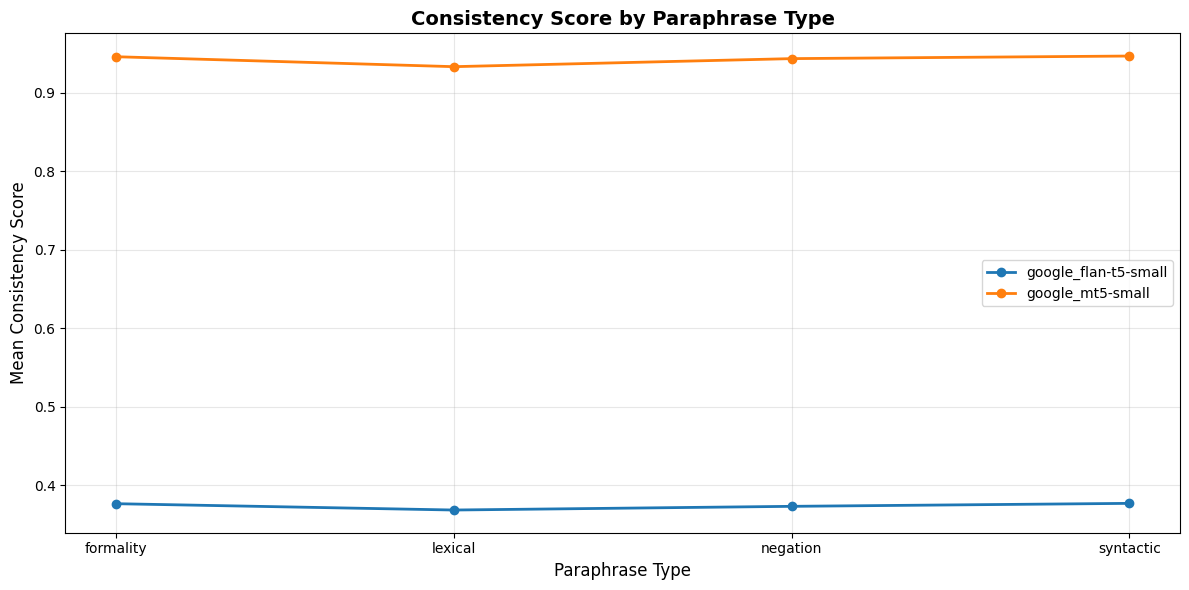

Saved: /content/drive/MyDrive/nlp_project_2/results/figures/consistency_by_task.png


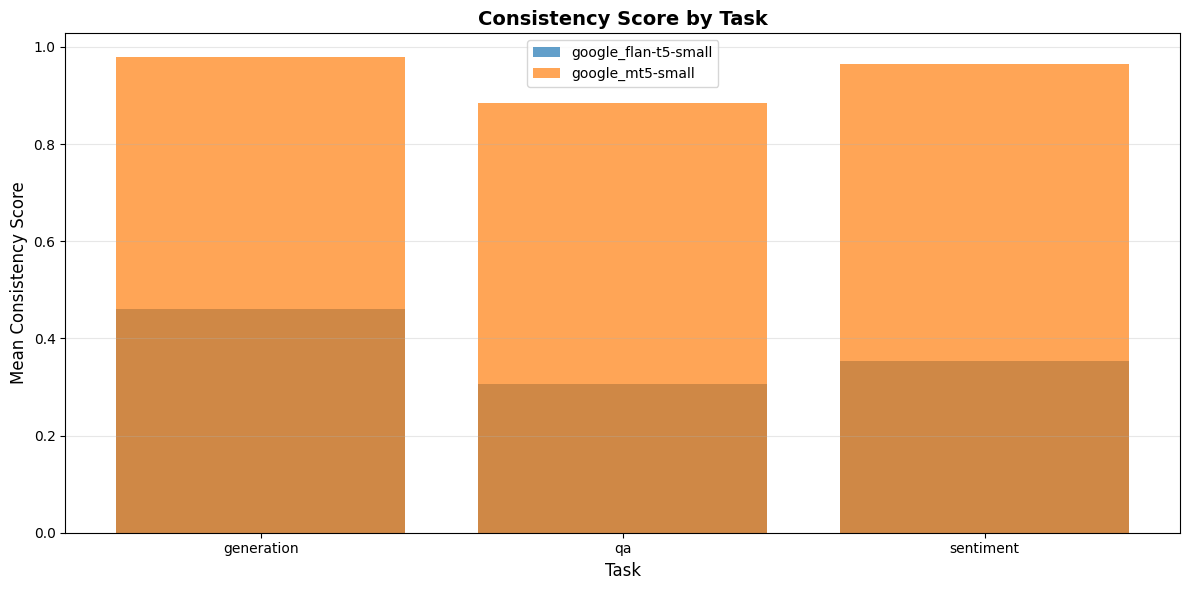

Saved: /content/drive/MyDrive/nlp_project_2/results/figures/heatmap_google_flan-t5-small.png


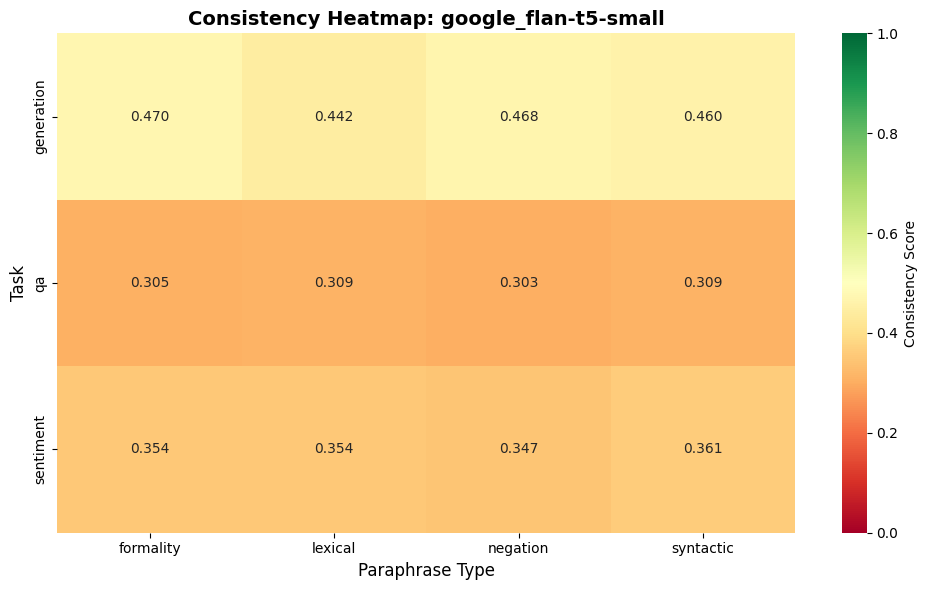

Saved: /content/drive/MyDrive/nlp_project_2/results/figures/heatmap_google_mt5-small.png


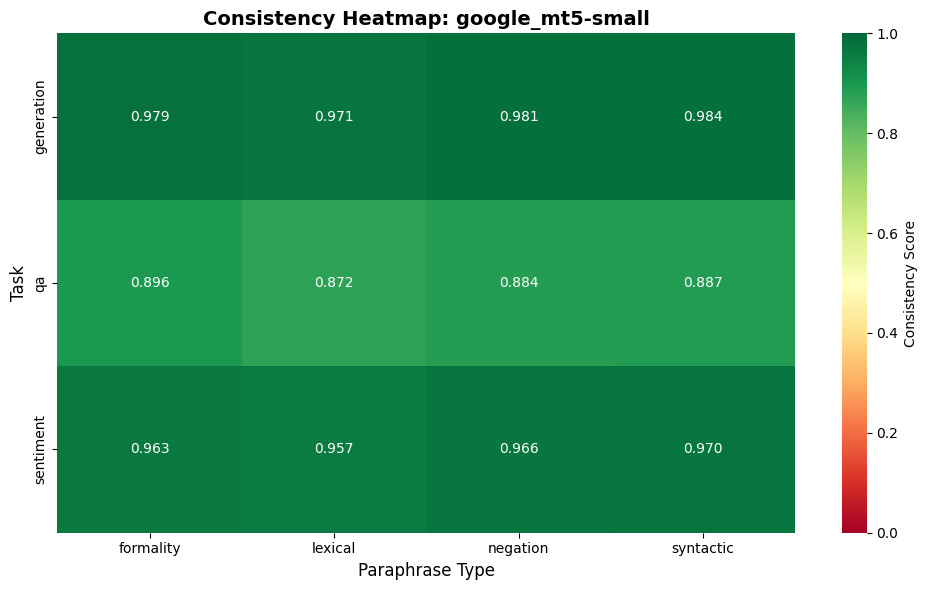


[Step 7/7] Performing error analysis...
Saved: /content/drive/MyDrive/nlp_project_2/results/error_analysis.json

Error Analysis Summary:

google_flan-t5-small:
  sentiment: 1034 failure cases (consistency < 0.5)
    By paraphrase type: {'lexical': 253, 'syntactic': 253, 'formality': 265, 'negation': 263}
  qa: 1147 failure cases (consistency < 0.5)
    By paraphrase type: {'lexical': 290, 'syntactic': 283, 'formality': 286, 'negation': 288}
  generation: 771 failure cases (consistency < 0.5)
    By paraphrase type: {'lexical': 215, 'negation': 179, 'syntactic': 195, 'formality': 182}

google_mt5-small:
  sentiment: 0 failure cases (consistency < 0.5)
  qa: 9 failure cases (consistency < 0.5)
    By paraphrase type: {'syntactic': 2, 'lexical': 3, 'negation': 2, 'formality': 2}
  generation: 2 failure cases (consistency < 0.5)
    By paraphrase type: {'lexical': 1, 'formality': 1}

 PIPELINE COMPLETE

Results saved to: /content/drive/MyDrive/nlp_project_2/results/


In [ ]:
results = run_full_pipeline(config)

## Additional Analysis: Ablation Study

In [ ]:
def ablation_study(stats_df: pd.DataFrame, config: Config):
    """Ablation study: remove each paraphrase type and measure impact"""

    print("\nAblation Study: Impact of Each Paraphrase Type")
    print("="*60)

    ablation_results = []

    for model in stats_df['model'].unique():
        model_data = stats_df[stats_df['model'] == model]

        # Baseline: all paraphrase types
        baseline_score = model_data['mean_consistency'].mean()

        print(f"\n{model}:")
        print(f"  Baseline (all paraphrase types): {baseline_score:.4f}")

        for para_type in config.paraphrase_types:
            # Remove this paraphrase type
            ablated_data = model_data[model_data['paraphrase_type'] != para_type]
            ablated_score = ablated_data['mean_consistency'].mean()

            impact = baseline_score - ablated_score

            print(f"  Without {para_type}: {ablated_score:.4f} (impact: {impact:+.4f})")

            ablation_results.append({
                'model': model,
                'removed_type': para_type,
                'baseline_score': baseline_score,
                'ablated_score': ablated_score,
                'impact': impact
            })

    # Save ablation results
    ablation_df = pd.DataFrame(ablation_results)
    ablation_df.to_csv(os.path.join(config.project_root, 'results/tables/ablation_study.csv'), index=False)

    return ablation_df


# Run ablation study
ablation_results = ablation_study(results['statistics'], config)


Ablation Study: Impact of Each Paraphrase Type

google_flan-t5-small:
  Baseline (all paraphrase types): 0.3735
  Without lexical: 0.3753 (impact: -0.0018)
  Without syntactic: 0.3724 (impact: +0.0011)
  Without formality: 0.3726 (impact: +0.0009)
  Without negation: 0.3737 (impact: -0.0002)

google_mt5-small:
  Baseline (all paraphrase types): 0.9426
  Without lexical: 0.9456 (impact: -0.0030)
  Without syntactic: 0.9411 (impact: +0.0015)
  Without formality: 0.9414 (impact: +0.0012)
  Without negation: 0.9422 (impact: +0.0004)


## Detailed Results Analysis

In [ ]:
def compute_detailed_analysis(
    evaluation_results: Dict,
    stats_df: pd.DataFrame,
    config: Config
) -> Dict:
    """
    Compute detailed statistical analysis for paper writing.
    Returns comprehensive breakdowns, significance tests, and error patterns.
    """

    cache_key = f'detailed_analysis_{config.num_samples_per_task}'
    cached = load_from_cache(cache_key)
    if cached is not None:
        return cached

    analysis = {}

    # --------------------------------------------------
    # 1. Statistical Significance Testing (ANOVA)
    # --------------------------------------------------
    print("\n[1/6] Computing statistical significance tests...")
    from scipy import stats
    from itertools import combinations

    groups_by_para = [
        stats_df[stats_df['paraphrase_type'] == para]['mean_consistency'].values
        for para in config.paraphrase_types
    ]

    f_stat, p_value = stats.f_oneway(*groups_by_para)

    analysis['anova_paraphrase'] = {
        'f_statistic': float(f_stat),
        'p_value': float(p_value),
        'significant': p_value < 0.05
    }

    # Pairwise comparisons (Bonferroni corrected)
    pairwise_comparisons = []
    n_comparisons = len(list(combinations(config.paraphrase_types, 2)))
    bonferroni_alpha = 0.05 / n_comparisons

    for para1, para2 in combinations(config.paraphrase_types, 2):
        scores1 = stats_df[stats_df['paraphrase_type'] == para1]['mean_consistency'].values
        scores2 = stats_df[stats_df['paraphrase_type'] == para2]['mean_consistency'].values

        result = stats.ttest_ind(scores1, scores2)

        t_stat = result.statistic
        p_val = result.pvalue

        pairwise_comparisons.append({
            'pair': f'{para1} vs {para2}',
            't_statistic': float(t_stat),
            'p_value': float(p_val),
            'significant_bonferroni': p_val < bonferroni_alpha,
            'mean_diff': float(np.mean(scores1) - np.mean(scores2))
        })

    analysis['pairwise_comparisons'] = pairwise_comparisons

    # --------------------------------------------------
    # 2. Detailed Error Analysis
    # --------------------------------------------------
    print("\n[2/6] Performing detailed error analysis...")

    error_analysis = {
        'by_category': {},
        'by_task': {},
        'by_model': {},
        'cross_model_failures': {}
    }

    failure_threshold = 0.5

    for model_name, model_data in evaluation_results.items():
        for task, samples in model_data.items():
            for sample in samples:
                for para_type, scores in sample['paraphrase_scores'].items():
                    consistency = scores['consistency_score']

                    # Category
                    cat = error_analysis['by_category'].setdefault(
                        para_type, {'total': 0, 'failures': 0, 'failure_rate': 0.0}
                    )
                    cat['total'] += 1
                    if consistency < failure_threshold:
                        cat['failures'] += 1

                    # Task
                    task_data = error_analysis['by_task'].setdefault(
                        task, {'total': 0, 'failures': 0, 'failure_rate': 0.0}
                    )
                    task_data['total'] += 1
                    if consistency < failure_threshold:
                        task_data['failures'] += 1

                    # Model
                    model_stats = error_analysis['by_model'].setdefault(
                        model_name, {'total': 0, 'failures': 0, 'failure_rate': 0.0}
                    )
                    model_stats['total'] += 1
                    if consistency < failure_threshold:
                        model_stats['failures'] += 1

    # Compute failure rates
    for group in ['by_category', 'by_task', 'by_model']:
        for entry in error_analysis[group].values():
            total = entry['total']
            entry['failure_rate'] = entry['failures'] / total if total > 0 else 0.0

    analysis['error_analysis'] = error_analysis

    # --------------------------------------------------
    # 3. Cross-model failure comparison
    # --------------------------------------------------
    print("\n[3/6] Analyzing cross-model failure patterns...")

    if len(config.models) >= 2:
        model_failures = {model.replace('/', '_'): set() for model in config.models}

        for model_name, model_data in evaluation_results.items():
            for task, samples in model_data.items():
                for idx, sample in enumerate(samples):
                    for para_type, scores in sample['paraphrase_scores'].items():
                        if scores['consistency_score'] < failure_threshold:
                            failure_id = f"{task}_{idx}_{para_type}"
                            model_failures[model_name].add(failure_id)

        model_list = [m.replace('/', '_') for m in config.models]
        shared_failures = set.intersection(*[model_failures[m] for m in model_list])

        cross_model_analysis = {
            'shared_failures': len(shared_failures),
            'unique_failures': {
                model: len(model_failures[model] - shared_failures)
                for model in model_list
            }
        }

        analysis['cross_model_failures'] = cross_model_analysis

    # --------------------------------------------------
    # 4. Task × Paraphrase interaction effects
    # --------------------------------------------------
    print("\n[4/6] Computing interaction effects...")

    interaction_matrix = {}

    for task in config.tasks:
        interaction_matrix[task] = {}

        for para_type in config.paraphrase_types:
            scores = stats_df[
                (stats_df['task'] == task) &
                (stats_df['paraphrase_type'] == para_type)
            ]['mean_consistency'].values

            interaction_matrix[task][para_type] = {
                'mean': float(np.mean(scores)) if len(scores) > 0 else 0.0,
                'std': float(np.std(scores)) if len(scores) > 0 else 0.0
            }

    analysis['task_paraphrase_interaction'] = interaction_matrix

    # --------------------------------------------------
    # 5. Rankings
    # --------------------------------------------------
    print("\n[5/6] Identifying best and worst performing configurations...")

    analysis['paraphrase_ranking'] = {
        'best': stats_df.groupby('paraphrase_type')['mean_consistency'].mean().idxmax(),
        'worst': stats_df.groupby('paraphrase_type')['mean_consistency'].mean().idxmin(),
        'all_rankings': stats_df.groupby('paraphrase_type')['mean_consistency'].mean().to_dict()
    }

    analysis['task_ranking'] = {
        'best': stats_df.groupby('task')['mean_consistency'].mean().idxmax(),
        'worst': stats_df.groupby('task')['mean_consistency'].mean().idxmin(),
        'all_rankings': stats_df.groupby('task')['mean_consistency'].mean().to_dict()
    }

    analysis['model_ranking'] = {
        'best': stats_df.groupby('model')['mean_consistency'].mean().idxmax(),
        'worst': stats_df.groupby('model')['mean_consistency'].mean().idxmin(),
        'all_rankings': stats_df.groupby('model')['mean_consistency'].mean().to_dict()
    }

    # --------------------------------------------------
    # 6. Export
    # --------------------------------------------------
    print("\n[6/6] Exporting detailed results to CSV...")

    os.makedirs(os.path.join(config.project_root, 'results/tables'), exist_ok=True)

    pd.DataFrame(pairwise_comparisons).to_csv(
        os.path.join(config.project_root, 'results/tables/pairwise_comparisons.csv'),
        index=False
    )

    pd.DataFrame([
        {
            'category': k,
            'total_cases': v['total'],
            'failures': v['failures'],
            'failure_rate': v['failure_rate']
        }
        for k, v in error_analysis['by_category'].items()
    ]).to_csv(
        os.path.join(config.project_root, 'results/tables/error_analysis_by_category.csv'),
        index=False
    )

    interaction_rows = [
        {
            'task': task,
            'paraphrase_type': para,
            'mean_consistency': stats_dict['mean'],
            'std_consistency': stats_dict['std']
        }
        for task, para_dict in interaction_matrix.items()
        for para, stats_dict in para_dict.items()
    ]

    pd.DataFrame(interaction_rows).to_csv(
        os.path.join(config.project_root, 'results/tables/task_paraphrase_interaction.csv'),
        index=False
    )

    save_results(json.loads(json.dumps(analysis, default=str)), 'detailed_analysis.json', 'results')
    save_to_cache(cache_key, analysis)

    print("\n Detailed analysis complete.")
    return analysis


print("Detailed analysis function defined.")

detailed_analysis = compute_detailed_analysis(
    evaluation_results=results['evaluation'],
    stats_df=results['statistics'],
    config=config
)
results['detailed_analysis'] = detailed_analysis

print("\n[ANOVA]", detailed_analysis['anova_paraphrase'])
print("\n[Pairwise Comparisons]")
for c in detailed_analysis['pairwise_comparisons']:
    print(f"  {c['pair']:30s}  p={c['p_value']:.4f}  sig={c['significant_bonferroni']}")
print("\n[Rankings - Paraphrase]", detailed_analysis['paraphrase_ranking']['all_rankings'])
print("\n[Rankings - Task]",       detailed_analysis['task_ranking']['all_rankings'])
print("\n[Rankings - Model]",      detailed_analysis['model_ranking']['all_rankings'])

Detailed analysis function defined.
Loading from cache: detailed_analysis_300

[ANOVA] {'f_statistic': 0.0015229519237409677, 'p_value': 0.9999149628977761, 'significant': np.False_}

[Pairwise Comparisons]
  lexical vs syntactic            p=0.9530  sig=False
  lexical vs formality            p=0.9558  sig=False
  lexical vs negation             p=0.9682  sig=False
  syntactic vs formality          p=0.9972  sig=False
  syntactic vs negation           p=0.9850  sig=False
  formality vs negation           p=0.9877  sig=False

[Rankings - Paraphrase] {'formality': 0.6611948208236093, 'lexical': 0.6508173485559946, 'negation': 0.6582975296850838, 'syntactic': 0.6618458417589043}

[Rankings - Task] {'generation': 0.7193575566750753, 'qa': 0.5956695973002212, 'sentiment': 0.6590895016423973}

[Rankings - Model] {'google_flan-t5-small': 0.37348098430181437, 'google_mt5-small': 0.9425967861099814}


## T-Test Isolating Formality

In [ ]:
def analyze_proposal_gaps(results, detailed_analysis, config):
    """Fill proposal gaps: RQ2 formality analysis + predictive analysis"""

    stats_df = results['statistics']
    gap_analysis = {}

    # ── RQ2: Formality Independent Analysis ───────────────────────────────
    print("="*60)
    print(" RQ2: Formality Independent Effect")
    print("="*60)

    from scipy import stats as scipy_stats

    formality_scores = stats_df[stats_df['paraphrase_type'] == 'formality']['mean_consistency'].values
    others_scores    = stats_df[stats_df['paraphrase_type'] != 'formality']['mean_consistency'].values

    formality_mean = float(np.mean(formality_scores))
    others_mean    = float(np.mean(others_scores))
    t_stat, p_val  = scipy_stats.ttest_ind(formality_scores, others_scores)

    gap_analysis['rq2_formality'] = {
        'formality_mean'  : formality_mean,
        'others_mean'     : others_mean,
        't_statistic'     : float(t_stat),
        'p_value'         : float(p_val),
        'significant'     : bool(p_val < 0.05),
        'conclusion'      : 'Formality independently significant' if p_val < 0.05
                            else 'Formality does NOT independently affect consistency'
    }

    print(f"  Formality mean consistency : {formality_mean:.4f}")
    print(f"  All others mean            : {others_mean:.4f}")
    print(f"  t-statistic                : {t_stat:.4f}")
    print(f"  p-value                    : {p_val:.4f}")
    print(f"  Conclusion                 : {gap_analysis['rq2_formality']['conclusion']}")

    # ── Predictive Analysis: Input Length vs Consistency ──────────────────
    print("\n" + "="*60)
    print(" Predictive Analysis: Input Features vs Consistency Failure")
    print("="*60)

    from scipy.stats import pearsonr

    lengths, scores, tasks, para_types = [], [], [], []

    for model_data in results['evaluation'].values():
        for task, task_samples in model_data.items():
            for sample in task_samples:
                for para_type, s in sample['paraphrase_scores'].items():
                    lengths.append(len(sample['input'].split()))
                    scores.append(s['consistency_score'])
                    tasks.append(task)
                    para_types.append(para_type)

    # Overall correlation
    r_overall, p_overall = pearsonr(lengths, scores)

    print(f"\n  [Overall] Input length vs consistency: r={r_overall:.4f}, p={p_overall:.4f}")

    # Per-task correlation
    task_correlations = {}
    print("\n  [Per Task]")
    for task in config.tasks:
        task_lengths = [l for l, t in zip(lengths, tasks) if t == task]
        task_scores  = [s for s, t in zip(scores,  tasks) if t == task]
        r, p = pearsonr(task_lengths, task_scores)
        task_correlations[task] = {'r': float(r), 'p': float(p)}
        print(f"    {task:12s}  r={r:.4f}  p={p:.4f}")

    # Per-paraphrase-type correlation
    para_correlations = {}
    print("\n  [Per Paraphrase Type]")
    for para in config.paraphrase_types:
        para_lengths = [l for l, pt in zip(lengths, para_types) if pt == para]
        para_scores  = [s for s, pt in zip(scores,  para_types) if pt == para]
        r, p = pearsonr(para_lengths, para_scores)
        para_correlations[para] = {'r': float(r), 'p': float(p)}
        print(f"    {para:12s}  r={r:.4f}  p={p:.4f}")

    # Lexical overlap: fraction of input words appearing in output
    print("\n  [Lexical Overlap: Input→Output vs Consistency]")

    def lexical_overlap(input_text: str, output_text: str) -> float:
        in_words  = set(input_text.lower().split())
        out_words = set(output_text.lower().split())
        return len(in_words & out_words) / len(in_words) if in_words else 0.0

    overlaps = []
    for model_data in results['evaluation'].values():
        for task, task_samples in model_data.items():
            for sample in task_samples:
                for para_type, s in sample['paraphrase_scores'].items():
                    ov = lexical_overlap(sample['input'], sample['original_output'])
                    overlaps.append(ov)

    r_ov, p_ov = pearsonr(overlaps, scores)
    print(f"    Overall  r={r_ov:.4f}  p={p_ov:.4f}")

    gap_analysis['predictive_analysis'] = {
        'overall'         : {'r': float(r_overall), 'p': float(p_overall)},
        'by_task'         : task_correlations,
        'by_paraphrase'   : para_correlations,
        'lexical_overlap'  : {'r': float(r_ov), 'p': float(p_ov)}
    }

    # ── Save ──────────────────────────────────────────────────────────────
    save_results(gap_analysis, 'gap_analysis.json', 'results')
    save_to_cache(f'gap_analysis_{config.num_samples_per_task}', gap_analysis)

    print("\n✓ Gap analysis saved.")
    return gap_analysis


# Call
gap_analysis = analyze_proposal_gaps(results, detailed_analysis, config)
results['gap_analysis'] = gap_analysis

 RQ2: Formality Independent Effect
  Formality mean consistency : 0.6612
  All others mean            : 0.6570
  t-statistic                : 0.0295
  p-value                    : 0.9767
  Conclusion                 : Formality does NOT independently affect consistency

 Predictive Analysis: Input Features vs Consistency Failure

  [Overall] Input length vs consistency: r=-0.0477, p=0.0001

  [Per Task]
    sentiment     r=-0.0296  p=0.1478
    qa            r=-0.0255  p=0.2122
    generation    r=0.0005  p=0.9803

  [Per Paraphrase Type]
    lexical       r=-0.0495  p=0.0357
    syntactic     r=-0.0333  p=0.1583
    formality     r=-0.0603  p=0.0105
    negation      r=-0.0477  p=0.0432

  [Lexical Overlap: Input→Output vs Consistency]
    Overall  r=-0.3418  p=0.0000
Saved: /content/drive/MyDrive/nlp_project_2/results/gap_analysis.json
Saved to cache: gap_analysis_300

✓ Gap analysis saved.


## Supplementary Analysis (Baselines + Predictive + Cross-Model Overlap)

In [ ]:
import random
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from scipy import stats as scipy_stats

# ── 1. Random Shuffle Baseline ─────────────────────────────────────────────
def random_shuffle_baseline(evaluation_results: Dict, config: Config) -> Dict:
    """
    Noise floor: shuffle output tokens randomly and measure self-consistency.
    Establishes how low consistency scores can go under pure noise.
    """
    print("=" * 60)
    print(" Baseline 1: Random Word-Order Shuffle")
    print("=" * 60)

    evaluator = ConsistencyEvaluator()
    baseline_scores = {}
    records = []

    for model_name, model_data in evaluation_results.items():
        model_scores = []
        for task, samples in model_data.items():
            for sample in samples:
                orig = sample['original_output']
                words = orig.split()
                if len(words) > 1:
                    shuffled_words = words.copy()
                    random.shuffle(shuffled_words)
                    shuffled = ' '.join(shuffled_words)
                    rouge = evaluator.compute_rouge(orig, shuffled)
                    model_scores.append(rouge['rougeL'])
                    records.append({
                        'model': model_name,
                        'task': task,
                        'rougeL_shuffle': rouge['rougeL']
                    })

        mean_score = float(np.mean(model_scores)) if model_scores else 0.0
        baseline_scores[model_name] = mean_score
        print(f"  {model_name}: {mean_score:.4f}  (noise floor)")

    # Save
    shuffle_df = pd.DataFrame(records)
    shuffle_df.to_csv(
        os.path.join(config.project_root, 'results/tables/shuffle_baseline.csv'),
        index=False
    )
    print(f"\n  Saved: results/tables/shuffle_baseline.csv")
    return baseline_scores

# ── 2. Syntactic Depth Correlation ────────────────────────────────────────
def syntactic_depth_correlation(evaluation_results: Dict, config: Config) -> Dict:
    """
    Predictive analysis: does output syntactic depth correlate with consistency failure?
    Uses spacy dependency parse on original outputs (already in memory via nlp).
    """
    print("\n" + "=" * 60)
    print(" Predictive Analysis: Syntactic Depth vs Consistency")
    print("=" * 60)

    def tree_depth(text: str) -> int:
        doc = nlp(text[:500])  # cap to avoid slow parses
        def depth(token):
            children = list(token.children)
            return 1 + max((depth(c) for c in children), default=0)
        roots = [t for t in doc if t.dep_ == 'ROOT']
        return max((depth(r) for r in roots), default=1)

    records = []

    for model_name, model_data in evaluation_results.items():
        for task, samples in model_data.items():
            for sample in samples:
                orig = sample['original_output']
                depth = tree_depth(orig)
                for pt, scores in sample['paraphrase_scores'].items():
                    records.append({
                        'model': model_name,
                        'task': task,
                        'paraphrase_type': pt,
                        'syntactic_depth': depth,
                        'consistency_score': scores['consistency_score']
                    })

    depth_df = pd.DataFrame(records)

    print("\n  Pearson correlation (syntactic depth vs consistency score):")
    for model_name in depth_df['model'].unique():
        subset = depth_df[depth_df['model'] == model_name]
        r, p = scipy_stats.pearsonr(subset['syntactic_depth'], subset['consistency_score'])
        sig = "significant" if p < 0.05 else "not significant"
        print(f"  {model_name}: r={r:.4f}, p={p:.4f} ({sig})")

    depth_df.to_csv(
        os.path.join(config.project_root, 'results/tables/syntactic_depth_correlation.csv'),
        index=False
    )
    print(f"\n  Saved: results/tables/syntactic_depth_correlation.csv")
    return depth_df

# ── 3. Cross-Model Failure Overlap ────────────────────────────────────────
def cross_model_failure_overlap(results: Dict, config: Config) -> Dict:
    """
    Proposal error analysis Q3: Do flan-t5 and mt5 break on the same inputs,
    or do they fail on different ones? Low overlap = architecture-specific failures.
    """
    print("\n" + "=" * 60)
    print(" Cross-Model Failure Overlap Analysis")
    print("=" * 60)

    model_failures = {}

    for model_name, model_errors in results['errors'].items():
        failure_inputs = set()
        for task, task_errors in model_errors.items():
            for sample in task_errors:
                failure_inputs.add(sample['input'][:100])  # truncate as key
        model_failures[model_name] = failure_inputs
        print(f"\n  {model_name}: {len(failure_inputs)} unique failing inputs")

    model_names = list(model_failures.keys())
    overlap_results = {}

    if len(model_names) == 2:
        m1, m2 = model_names
        shared    = model_failures[m1] & model_failures[m2]
        m1_only   = model_failures[m1] - model_failures[m2]
        m2_only   = model_failures[m2] - model_failures[m1]
        total     = model_failures[m1] | model_failures[m2]
        jaccard   = len(shared) / len(total) if total else 0.0

        print(f"\n  Shared failures (both models) : {len(shared)}")
        print(f"  {m1} only : {len(m1_only)}")
        print(f"  {m2} only : {len(m2_only)}")
        print(f"  Jaccard overlap index         : {jaccard:.4f}")

        if jaccard < 0.2:
            conclusion = "Low overlap — models fail on architecturally distinct inputs"
        elif jaccard < 0.5:
            conclusion = "Moderate overlap — partial shared failure patterns"
        else:
            conclusion = "High overlap — models share common failure inputs"

        print(f"  Conclusion: {conclusion}")

        overlap_results = {
            'shared': len(shared),
            f'{m1}_only': len(m1_only),
            f'{m2}_only': len(m2_only),
            'jaccard': jaccard,
            'conclusion': conclusion
        }

        # Save
        import json
        save_path = os.path.join(config.project_root, 'results/cross_model_overlap.json')
        with open(save_path, 'w') as f:
            json.dump(overlap_results, f, indent=2)
        print(f"\n  Saved: results/cross_model_overlap.json")

    return overlap_results


# ── Run all Block 22 analyses ──────────────────────────────────────────────
shuffle_scores  = random_shuffle_baseline(results['evaluation'], config)
depth_df        = syntactic_depth_correlation(results['evaluation'], config)
overlap_results = cross_model_failure_overlap(results, config)

 Baseline 1: Random Word-Order Shuffle
  google_flan-t5-small: 0.3582  (noise floor)
  google_mt5-small: 0.8218  (noise floor)

  Saved: results/tables/shuffle_baseline.csv

 Predictive Analysis: Syntactic Depth vs Consistency

  Pearson correlation (syntactic depth vs consistency score):
  google_flan-t5-small: r=0.4219, p=0.0000 (significant)
  google_mt5-small: r=-0.5715, p=0.0000 (significant)

  Saved: results/tables/syntactic_depth_correlation.csv

 Cross-Model Failure Overlap Analysis

  google_flan-t5-small: 602 unique failing inputs

  google_mt5-small: 9 unique failing inputs

  Shared failures (both models) : 9
  google_flan-t5-small only : 593
  google_mt5-small only : 0
  Jaccard overlap index         : 0.0150
  Conclusion: Low overlap — models fail on architecturally distinct inputs

  Saved: results/cross_model_overlap.json


## Summary Report

In [ ]:
def generate_summary_report(results: Dict, config: Config,
                             gap_analysis: Dict = None,
                             shuffle_scores: Dict = None,
                             depth_df=None,
                             overlap_results=None):
    """Comprehensive summary report including Block 21 and Block 22 results"""

    stats_df = results['statistics']
    report = []

    report.append("=" * 70)
    report.append(" PROJECT SUMMARY REPORT")
    report.append("=" * 70)

    # ── Setup ──────────────────────────────────────────────────────────────
    report.append("\n## Research Questions")
    report.append("  RQ1: Do different paraphrase types produce systematically different")
    report.append("       levels of output inconsistency in small LLMs?")
    report.append("  RQ2: Does input formality independently influence output consistency?")
    report.append("  RQ3: Is inconsistency a property of the model or the task?")

    report.append("\n## Experimental Setup")
    report.append(f"  Models  : {', '.join(config.models)}")
    report.append(f"  Tasks   : {', '.join(config.tasks)}")
    report.append(f"  Para.   : {', '.join(config.paraphrase_types)}")
    report.append(f"  Samples : {config.num_samples_per_task} per task "
                  f"({config.num_samples_per_task * len(config.tasks)} total)")

    # ── RQ1: Paraphrase Type Effect ────────────────────────────────────────
    report.append("\n" + "=" * 70)
    report.append(" RQ1: Paraphrase Type vs Output Consistency")
    report.append("=" * 70)

    para_means = stats_df.groupby('paraphrase_type')['mean_consistency'].mean().sort_values(ascending=False)
    for pt, score in para_means.items():
        report.append(f"  {pt:12s}: {score:.4f}")

    # ANOVA result from detailed_analysis if available
    if 'detailed_analysis' in results and isinstance(results['detailed_analysis'], dict) and 'anova_paraphrase' in results['detailed_analysis']:
        anova = results['detailed_analysis']['anova_paraphrase']
        sig = "significant" if anova['significant'] else "not significant"
        report.append(f"\n  ANOVA: F={anova['f_statistic']:.4f}, "
                      f"p={anova['p_value']:.4f} ({sig})")

    # ── RQ2: Formality Independent Effect (Block 21) ───────────────────────
    report.append("\n" + "=" * 70)
    report.append(" RQ2: Formality Independent Effect (t-test)")
    report.append("=" * 70)

    if gap_analysis and 'rq2_formality' in gap_analysis:
        rq2 = gap_analysis['rq2_formality']
        report.append(f"  Formality mean consistency : {rq2['formality_mean']:.4f}")
        report.append(f"  All others mean            : {rq2['others_mean']:.4f}")
        report.append(f"  t-statistic                : {rq2['t_statistic']:.4f}")
        report.append(f"  p-value                    : {rq2['p_value']:.4f}")
        report.append(f"  Conclusion                 : {rq2['conclusion']}")
    else:
        report.append("  (Run Block 21 to populate this section)")

    # ── RQ3: Task and Model Breakdown ──────────────────────────────────────
    report.append("\n" + "=" * 70)
    report.append(" RQ3: Inconsistency by Task and Model")
    report.append("=" * 70)

    report.append("\n  By Task:")
    task_means = stats_df.groupby('task')['mean_consistency'].mean().sort_values(ascending=False)
    for task, score in task_means.items():
        report.append(f"    {task:12s}: {score:.4f}")

    report.append("\n  By Model:")
    model_means = stats_df.groupby('model')['mean_consistency'].mean().sort_values(ascending=False)
    for model, score in model_means.items():
        report.append(f"    {model}: {score:.4f}")

    # ── Baselines (Block 22) ───────────────────────────────────────────────
    report.append("\n" + "=" * 70)
    report.append(" Baselines")
    report.append("=" * 70)

    if shuffle_scores:
        report.append("\n  Random Shuffle Noise Floor (rougeL):")
        for model, score in shuffle_scores.items():
            actual = model_means.get(model, None)
            delta = f" (+{actual - score:.4f} above noise)" if actual else ""
            report.append(f"    {model}: {score:.4f}{delta}")
    else:
        report.append("  (Run Block 22 shuffle baseline to populate)")

    # ── Predictive Analysis: Syntactic Depth ──────────────────────────────
    report.append("\n" + "=" * 70)
    report.append(" Predictive Analysis: Syntactic Depth vs Consistency")
    report.append("=" * 70)

    if depth_df is not None:
        from scipy import stats as scipy_stats
        for model_name in depth_df['model'].unique():
            subset = depth_df[depth_df['model'] == model_name]
            r, p = scipy_stats.pearsonr(subset['syntactic_depth'], subset['consistency_score'])
            sig = "significant" if p < 0.05 else "not significant"
            direction = "positive" if r > 0 else "negative"
            report.append(f"  {model_name}:")
            report.append(f"    r={r:.4f}, p={p:.4f} ({sig}, {direction} correlation)")
    else:
        report.append("  (Run Block 22 depth analysis to populate)")

    # ── Predictive Analysis: Lexical Overlap ──────────────────────────────
    report.append("\n" + "=" * 70)
    report.append(" Predictive Analysis: Lexical Overlap vs Consistency")
    report.append("=" * 70)

    if gap_analysis and 'lexical_overlap' in gap_analysis.get('predictive_analysis', {}):
        lov = gap_analysis['predictive_analysis']['lexical_overlap']
        sig = "significant" if lov['p'] < 0.05 else "not significant"
        report.append(f"  r={lov['r']:.4f}, p={lov['p']:.4f} ({sig})")
    else:
        report.append("  (Run Block 21 lexical overlap analysis to populate)")

    # ── Cross-Model Overlap ─────────────────────────────────────────
    report.append("\n" + "=" * 70)
    report.append(" Cross-Model Failure Overlap")
    report.append("=" * 70)

    if overlap_results:
        report.append(f"  Shared failures        : {overlap_results['shared']}")
        report.append(f"  Jaccard overlap index  : {overlap_results['jaccard']:.4f}")
        report.append(f"  Conclusion             : {overlap_results['conclusion']}")
    else:
        report.append("  (Run Block 22 overlap analysis to populate)")

    # ── Error Analysis ─────────────────────────────────────────────────────
    report.append("\n" + "=" * 70)
    report.append(" Error Analysis (Consistency < 0.5)")
    report.append("=" * 70)

    errors = results['errors']
    for model_name, model_errors in errors.items():
        total_errors = sum(len(e) for e in model_errors.values())
        report.append(f"  {model_name}: {total_errors} failure cases")
        for task, task_errors in model_errors.items():
            report.append(f"    {task:12s}: {len(task_errors)}")

    report.append("\n" + "=" * 70)
    report.append(" END OF REPORT")
    report.append("=" * 70)

    # Print and save
    report_text = "\n".join(report)
    print(report_text)

    report_path = os.path.join(config.project_root, 'results/summary_report.txt')
    with open(report_path, 'w') as f:
        f.write(report_text)
    print(f"\nReport saved to: {report_path}")
    return report_text


# Run
report = generate_summary_report(
    results=results,
    config=config,
    gap_analysis=gap_analysis,
    shuffle_scores=shuffle_scores,
    depth_df=depth_df,
    overlap_results=overlap_results
)

 PROJECT SUMMARY REPORT

## Research Questions
  RQ1: Do different paraphrase types produce systematically different
       levels of output inconsistency in small LLMs?
  RQ2: Does input formality independently influence output consistency?
  RQ3: Is inconsistency a property of the model or the task?

## Experimental Setup
  Models  : google/flan-t5-small, google/mt5-small
  Tasks   : sentiment, qa, generation
  Para.   : lexical, syntactic, formality, negation
  Samples : 300 per task (900 total)

 RQ1: Paraphrase Type vs Output Consistency
  syntactic   : 0.6618
  formality   : 0.6612
  negation    : 0.6583
  lexical     : 0.6508

  ANOVA: F=0.0015, p=0.9999 (not significant)

 RQ2: Formality Independent Effect (t-test)
  Formality mean consistency : 0.6612
  All others mean            : 0.6570
  t-statistic                : 0.0295
  p-value                    : 0.9767
  Conclusion                 : Formality does NOT independently affect consistency

 RQ3: Inconsistency by Task and

## Project Completion and saving are as follows:

All results have been saved to the `results/` directory:
- `results/tables/` - CSV files with aggregate statistics
- `results/figures/` - Visualizations (PNG)
- `results/` - JSON files with detailed results
- `results/summary_report.txt` - Text summary of key findings
